# scrna_matrix + Scanpy / AnnData

End-to-end k-NN graph construction on an `AnnData` object using the
`Block_CSR` engine, written back into `adata.obsp` / `adata.uns` in the layout
scanpy expects so that `sc.tl.leiden`, `sc.tl.umap` and friends work unchanged.

**Requires**: the CMake project built with `-DSCRNA_BUILD_PYTHON=ON`, with the
build directory and `examples/` on `PYTHONPATH`:

```bash
cmake -S . -B build -DCMAKE_BUILD_TYPE=Release && cmake --build build -j
PYTHONPATH=build:examples jupyter lab examples/scanpy_integration.ipynb
```

**Two k-NN methods** are available and this notebook exercises both:

* `method="brute"` — exact, deterministic, O(n_obs²). Sections 1-5.
* `method="hnsw"` — approximate, near-linear, via vendored `hnswlib`. Section 6,
  including the measurement showing which representation it belongs on.

Section 6 also covers the crossover: which method to use at which scale, and the
case where HNSW is the *wrong* choice. See `docs/BENCHMARKS.md` for full tables.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import scanpy as sc

import scrna_matrix_py as scrna
from scrna_anndata import neighbors as scrna_neighbors
from scrna_anndata import knn_arrays

sc.settings.verbosity = 0
print("scrna_matrix SIMD kernel selected at runtime:", scrna.simd_isa())

scrna_matrix SIMD kernel selected at runtime: scalar


## 1. Load and preprocess a real dataset

`pbmc3k` (~2,700 PBMCs, 10x Genomics) with a standard scanpy preprocessing
path: filter, normalise, log-transform, then restrict to highly variable genes.
The matrix stays sparse CSR throughout, which is what `Block_CSR` consumes.

In [2]:
adata = sc.datasets.pbmc3k()
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=1000)
adata = adata[:, adata.var.highly_variable].copy()

print(adata)
print(f"\nshape={adata.shape}  nnz={adata.X.nnz}  density={adata.X.nnz / np.prod(adata.shape):.3%}")

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2700 × 1000
    var: 'gene_ids', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

shape=(2700, 1000)  nnz=186216  density=6.897%


## 2. Wrap the expression matrix in a Block_CSR

`to_aligned` returns 64-byte-aligned copies of the three CSR buffers, which lets
`BlockCSR` adopt them in place rather than copying again. `is_zero_copy` reports
which path was actually taken, so this is checkable rather than assumed.

(NumPy >= 2 already returns 64-byte-aligned allocations at realistic sizes, so
adoption often happens without `to_aligned`. It is not a guarantee NumPy makes,
which is why the explicit call is here.)

In [3]:
from scrna_anndata import blockcsr_from_anndata

mat, keepalive = blockcsr_from_anndata(adata)
print(f"shape={mat.shape}  nnz={mat.nnz}  is_zero_copy={mat.is_zero_copy}")

# `keepalive` owns the buffers `mat` borrows; it must stay referenced while
# `mat` is in use. The C++ side holds a reference too, so this is belt-and-braces.
print("backing buffers:", [a.dtype for a in keepalive])

shape=(2700, 1000)  nnz=186216  is_zero_copy=True
backing buffers: [dtype('float32'), dtype('int32'), dtype('int32')]


## 3. Build the k-NN graph and write it back into AnnData

`scrna_neighbors` is the drop-in equivalent of `sc.pp.neighbors`: it computes the
graph with the Block_CSR engine and populates `obsp['distances']`,
`obsp['connectivities']` and `uns['neighbors']`.

Connectivities come from scanpy's own fuzzy-simplicial-set routine, so they are
identical to what `sc.pp.neighbors` would have produced for the same neighbour
sets — `uns['neighbors']['params']['connectivity_impl']` records this.

In [4]:
K = 15

# Time the engine itself, separately from the AnnData conversion. The first
# conversion pays a one-off numba JIT cost inside scanpy's fuzzy-simplicial-set
# routine (several seconds) that has nothing to do with the k-NN search, so it is
# warmed up before being measured rather than being charged to the engine.
t0 = time.perf_counter()
_idx, _sim = knn_arrays(adata, n_neighbors=K)
knn_elapsed = time.perf_counter() - t0

scrna_neighbors(adata, n_neighbors=K)          # warm up the JIT
t0 = time.perf_counter()
scrna_neighbors(adata, n_neighbors=K)          # measured
elapsed = time.perf_counter() - t0

print(f"k-NN search only (exact cosine, {K} neighbours): {knn_elapsed:.3f} s")
print(f"search + AnnData conversion (JIT warm):          {elapsed:.3f} s")

print("\nobsp:", list(adata.obsp.keys()))
print("uns['neighbors']:")
for k, v in adata.uns["neighbors"].items():
    print(f"  {k}: {v}")

dist = adata.obsp["distances"]
conn = adata.obsp["connectivities"]
print(f"\ndistances:      {dist.shape} {dist.dtype}  {dist.nnz / adata.n_obs:.1f} entries/cell")
print(f"connectivities: {conn.shape} {conn.dtype}  {conn.nnz / adata.n_obs:.1f} entries/cell")
print(f"connectivities symmetric: {abs(conn - conn.T).max() == 0}")

k-NN search only (exact cosine, 15 neighbours): 0.034 s
search + AnnData conversion (JIT warm):          0.042 s

obsp: ['distances', 'connectivities']
uns['neighbors']:
  connectivities_key: connectivities
  distances_key: distances
  params: {'n_neighbors': 16, 'metric': 'cosine', 'method': 'scrna_matrix_brute', 'use_rep': 'X', 'connectivity_impl': 'scanpy.umap', 'exact': True, 'random_state': 0, 'simd': 'scalar'}

distances:      (2700, 2700) float64  15.0 entries/cell
connectivities: (2700, 2700) float32  26.3 entries/cell
connectivities symmetric: True


## 4. Downstream scanpy tools run against our graph

This is the part that makes it a real integration rather than a matching set of
array shapes: clustering, embedding and trajectory tools consume the graph
directly, with no awareness that it came from a different backend.

In [5]:
sc.tl.leiden(adata, key_added="leiden_scrna", flavor="igraph", n_iterations=2, directed=False)
print("leiden clusters:", adata.obs.leiden_scrna.nunique())

sc.tl.umap(adata)
print("UMAP embedding:", adata.obsm["X_umap"].shape)

sc.tl.paga(adata, groups="leiden_scrna")
print("PAGA connectivities:", adata.uns["paga"]["connectivities"].shape)

leiden clusters: 6


UMAP embedding: (2700, 2)
PAGA connectivities: (6, 6)


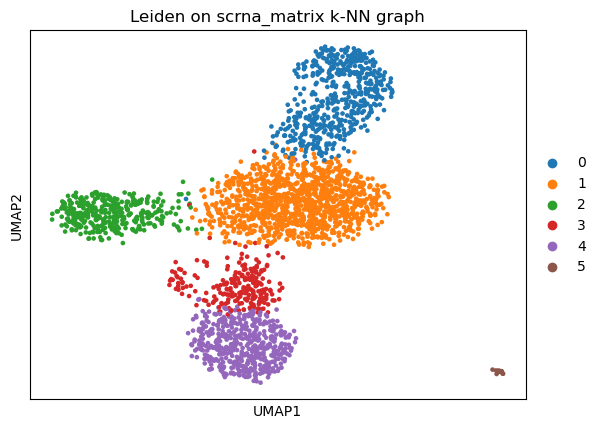

In [6]:
sc.pl.umap(adata, color="leiden_scrna", title="Leiden on scrna_matrix k-NN graph", show=True)

## 5. Cross-check against `sc.pp.neighbors`

The comparison is only meaningful on the *same representation*. By default
`sc.pp.neighbors` runs on a 50-component PCA, so it must be pointed at `X` with
`use_rep="X"` to be compared against a graph built from `X`.

`scrna_matrix` computes exact neighbours; `sc.pp.neighbors` uses approximate
nearest-neighbour search, so agreement is a check on scanpy's approximation
quality as much as on ours.

In [7]:
ref = adata.copy()

# Both backends are JIT-warmed before measurement, so neither is charged for
# numba compilation.
sc.pp.neighbors(ref, n_neighbors=K + 1, metric="cosine", use_rep="X")
t0 = time.perf_counter()
sc.pp.neighbors(ref, n_neighbors=K + 1, metric="cosine", use_rep="X")
ref_elapsed = time.perf_counter() - t0

ours = adata.obsp["distances"] > 0
theirs = ref.obsp["distances"] > 0
overlap = ours.multiply(theirs).sum() / ours.sum()

print(f"scrna_matrix, search only (exact):   {knn_elapsed:.3f} s")
print(f"scrna_matrix, search + conversion:   {elapsed:.3f} s")
print(f"sc.pp.neighbors (approximate):       {ref_elapsed:.3f} s")
print(f"neighbour-set overlap:               {overlap:.4f}")
print()
print("Exact and approximate agree on this dataset. Brute force is competitive")
print("at a few thousand cells; see the closing section for why that does not")
print("extrapolate to 1M cells.")

scrna_matrix, search only (exact):   0.034 s
scrna_matrix, search + conversion:   0.042 s
sc.pp.neighbors (approximate):       0.246 s
neighbour-set overlap:               1.0000

Exact and approximate agree on this dataset. Brute force is competitive
at a few thousand cells; see the closing section for why that does not
extrapolate to 1M cells.


## 6. Scaling up: approximate k-NN with HNSW

Exact brute force is O(n_obs²), so it runs out of road well before a million
cells. `method="hnsw"` swaps in an HNSW index (vendored `hnswlib`) for
near-linear scaling.

One property of hnswlib decides how to use it: **it indexes dense,
fixed-dimension vectors — it has no sparse representation.** Two consequences:

* memory is `n_obs × n_dims × 4` bytes no matter how sparse the input was;
* every distance is an `n_dims`-wide dense operation, whereas the exact path
  touches only the ~70 non-zeros in a row.

So running HNSW in full gene space discards exactly the sparsity that makes the
exact path fast. The measurements below show it losing there. Run it on a
**PCA embedding** instead, which is also what `sc.pp.neighbors` does by default.

In [8]:
print("HNSW compiled in:", scrna.has_hnsw())

for n_dims, label in [(1000, "gene space (HVG)"), (50, "PCA embedding")]:
    est = scrna.hnsw_index_bytes(1_300_000, n_dims) / 2**30
    print(f"  index for 1.3M cells x {n_dims:>4} dims ({label:<18}): {est:6.2f} GB")

HNSW compiled in: True
  index for 1.3M cells x 1000 dims (gene space (HVG)  ):   5.09 GB
  index for 1.3M cells x   50 dims (PCA embedding     ):   0.49 GB


In [9]:
# Gene space: HNSW is available, but is it actually the right call here?
t0 = time.perf_counter()
idx_h, sim_h = knn_arrays(adata, n_neighbors=K, method="hnsw")
hnsw_gene_s = time.perf_counter() - t0

idx_e, _ = knn_arrays(adata, n_neighbors=K)          # exact, for recall
recall = np.mean([len(set(a) & set(b)) for a, b in zip(idx_h, idx_e)]) / K

print(f"exact, sparse gene space : {knn_elapsed:.3f} s")
print(f"HNSW,  dense gene space  : {hnsw_gene_s:.3f} s   (recall {recall:.3f})")
print()
print("HNSW is slower here: densifying 1,000 gene dimensions costs more per")
print("distance than the exact sparse gather saves in comparisons.")

exact, sparse gene space : 0.034 s
HNSW,  dense gene space  : 0.338 s   (recall 0.988)

HNSW is slower here: densifying 1,000 gene dimensions costs more per
distance than the exact sparse gather saves in comparisons.


In [10]:
# PCA embedding: the configuration HNSW is built for.
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=50)
print("X_pca:", adata.obsm["X_pca"].shape)

scrna_neighbors(adata, n_neighbors=K, method="hnsw", use_rep="X_pca")  # warm up
t0 = time.perf_counter()
scrna_neighbors(adata, n_neighbors=K, method="hnsw", use_rep="X_pca")
hnsw_pca_s = time.perf_counter() - t0

print(f"HNSW on 50-dim PCA: {hnsw_pca_s:.3f} s")
print("params:", adata.uns["neighbors"]["params"])

sc.tl.leiden(adata, key_added="leiden_hnsw", flavor="igraph", n_iterations=2, directed=False)
print("leiden on the HNSW graph:", adata.obs.leiden_hnsw.nunique(), "clusters")

X_pca: (2700, 50)


HNSW on 50-dim PCA: 0.040 s
params: {'n_neighbors': 16, 'metric': 'cosine', 'method': 'scrna_matrix_hnsw', 'use_rep': 'X_pca', 'connectivity_impl': 'scanpy.umap', 'exact': False, 'random_state': 0, 'simd': 'scalar'}
leiden on the HNSW graph: 7 clusters


### Where the crossover actually is

Measured on this machine (Apple M4 Pro, 12 threads, scalar SIMD path), k=15.
Full tables are in `docs/BENCHMARKS.md`.

On a 50-dimensional embedding with cluster structure:

| Cells | Exact brute force | HNSW | Speed-up | HNSW recall |
|---|---|---|---|---|
| 10,000 | 0.25 s | 0.11 s | 2.4x | 1.000 |
| 25,000 | 1.57 s | 0.25 s | 6.4x | 0.999 |
| 50,000 | 6.32 s | 0.57 s | 11.2x | 0.997 |
| 200,000 | ~100 s (extrapolated) | 3.65 s | ~28x | — |
| **1,300,000** | **~1.6 h (extrapolated)** | **37.1 s** | **~155x** | — |

The 1.3M-cell run is real, not extrapolated: 37.1 s at **1.01 GB peak RSS**.
That is the 1M+ target met — on an embedding, with an approximate method.

In 1,000-dimensional gene space the ordering inverts and HNSW is 4-20x *slower*
than the exact path, because each dense distance costs ~16x more than the sparse
gather it replaces. Pick the method to match the representation.

## 7. Scope and honest limits

What this notebook demonstrates, at ~2,700 cells:

* the expression matrix is handed to `Block_CSR` without a redundant copy
  (`is_zero_copy == True`);
* the resulting graph is written back in scanpy's own layout, and `leiden`,
  `umap` and `paga` all consume it;
* neighbours agree with `sc.pp.neighbors` on the same representation.

* HNSW reaches 1.3M cells in 37 s at ~1 GB, on a 50-dim embedding.

What it does **not** demonstrate:

* **HNSW recall on real data at scale.** Recall was measured against exact
  results only up to 50k cells (0.997 there). Beyond that there is no exact
  baseline to compare against, precisely because computing one is infeasible.
  Recall also degrades as dimensionality rises and cluster structure weakens —
  on 1,000-dim random data it fell to 0.62 at 40k cells. Validate recall on a
  subsample of your own data before trusting the graph.
* **Determinism under HNSW.** Multi-threaded index construction depends on
  insertion order, so the graph varies between runs. `method="brute"` remains
  the reproducible option; pin `num_threads=1` for a deterministic HNSW build.
* **A general speedup claim over scanpy.** `sc.pp.neighbors` on PCA is also
  approximate and also near-linear; it is a peer of `method="hnsw"`, not a
  baseline it dominates. The exact path is the one offering something different:
  ground truth.

Rule of thumb: exact brute force up to a few tens of thousands of cells, HNSW on
a PCA embedding beyond that, and never HNSW on wide gene-space input.